# 2D Taylor-Green

In [1]:
import numpy as np
import matplotlib.pylab as plt
import matplotlib.colors
from IPython.display import display, Math, Latex
import time
Nx=40
Ny=Nx
# ---------------------------Lattice-Properties--------------------------------------------
w0=4.0/9.0;w1=1.0/9.0;w2=1.0/36.0; # Lattice Weights
w = np.array([w0,w1,w1,w1,w1,w2,w2,w2,w2],dtype="float64") 
cx = np.array([0,1,0,-1, 0,1,-1,-1, 1],dtype="int8")  # Lattice Directions
cy = np.array([0,0,1, 0,-1,1, 1,-1,-1],dtype="int8")  # Lattice Directions
# opp = np.array([0,3,4,1,2,7,8,5,6],dtype="uint8")  # Opposite Lattice Directions
#------------Dimensionless Parameter For Pro----------------
uo = 1.0 # Dimensionless Velocity
ho = 1.0 # Dimensionless Domain Length
Re = 30.0 # Reynolds Number
nuo = uo*ho/Re #Dimensionless Kinematic Viscosity
#------------------------------------------Scaling Term--------------------------------------------
dx = ho / (Nx) # Grid size 
r = 2.0**(3) # Relation term r=dx/dt
dt = dx / r # Time Step
#----------------------------------------LBM-Scale-----------------------------------------------
nu = dt * nuo / (dx * dx)  #Scaling Viscosity
ue = dt * uo / dx  #Scaling Velocity
cs = 1.0 / np.sqrt(3.) #Sound Speed
tau = (nu/ (cs * cs)) + (1.0/ 2.0) #Relaxation time
rhoi = 1.0 #Initial Densty
mstep=10
#--------------Print-Data-------------------------------------------------------------------------
display(Math(r"\tau="+str(tau)+r"\quad\quad \nu="+str(nu)))
display(Math(r"r="+str(r)+r"\quad\quad \overline{u}="+str(ue)))
display(Math(r"dx="+str(dx)+r"\quad\quad dt="+str(dt)))
#---------------------Field-Arrays---------------------------------------------------------------- 
Mass=np.zeros((mstep),dtype="float64") # Allocating Density field
Enr=np.zeros((mstep),dtype="float64") # Allocating Density field
rho=np.zeros((Nx,Ny),dtype="float64") # Allocating Density field
Vx=np.zeros((Nx,Ny),dtype="float64") # Allocating Null Velocity x Field
Vy=np.zeros((Nx,Ny),dtype="float64") # Allocating Null Velocity y Field
# ----------------------------Init Field------------------------------------------------------
xi = np.arange(Nx, dtype="float64") + 0.5
yi = np.arange(Ny, dtype="float64") + 0.5
Xi, Yi = np.meshgrid(xi, yi, indexing="ij")
rho = rhoi - (rhoi * ue**2 / (4.0 * cs**2)) * (np.cos(4.0 * np.pi * Xi / Nx) + np.cos(4.0 * np.pi * Yi / Ny))    # Density
Vx = -ue * (np.cos(2.0 * np.pi * Xi / Nx) * np.sin(2.0 * np.pi * Yi / Ny)) # Velocity X
Vy = ue * (np.cos(2.0 * np.pi * Yi / Ny) * np.sin(2.0 * np.pi * Xi / Nx)) # Velocity Y
#----------------Initializing Distribution Functions----------------
f=np.zeros((9,Nx,Ny),dtype="float64") # Allocating Pre-Collisional Distribution Function
fp=np.zeros((9,Nx,Ny),dtype="float64") # Allocating Pos-Collisional Distribution Function
feq=np.zeros((9,Nx,Ny),dtype="float64") # Allocating Pos-Collisional Distribution Function
for k in range (0,9):
    f[k,:,:]=w[k]*rho*(1. + 3.*(Vx*cx[k]+Vy*cy[k]) + 4.5*(Vx*cx[k]+Vy*cy[k])**2-1.5*(Vx*Vx+Vy*Vy))
#---------------------------------Main-Loop-------------------------------------------------------
En=0.0; 
start=time.time()
for kk in range(0,mstep):
    #------------------------------------Collision-----------------------------------------------------------------------------
    for k in range(0,9):
        feq[k,:,:]=w[k]*rho*(1. + 3.*(Vx*cx[k]+Vy*cy[k]) + 4.5*(Vx*cx[k]+Vy*cy[k])**2-1.5*(Vx*Vx+Vy*Vy))
        # feq[k,:,:]=w[k]*rho*(1.0 + 3.0*(Vx*cx[k]+Vy*cy[k]) + 4.5*(Vx*cx[k]*Vx*cx[k]) - 1.5*(Vx*Vx+Vy*Vy))
        # feq[k,:,:]=w[k]*rho*(1.0 + 3.0*(Vx*cx[k]+Vy*cy[k]) - 1.5*(Vx*Vx+Vy*Vy))
        fp[k,:,:]=f[k,:,:]-(1.0/tau)*(f[k,:,:]-feq[k,:,:])
    #----------------------------------Streaming---------------------------------------------------------------------------
    for k in range(0,9):
        f[k,:,:]=np.roll(np.roll(fp[k,:,:], cx[k], axis=0), cy[k], axis=1)
    #--------------------------------------Macro-Properties------------------------------------------------------------------
    rho=np.einsum('ixy->xy', f)
    Vx=np.einsum('i,ixy->xy', cx, f)/rho
    Vy=np.einsum('i,ixy->xy', cy, f)/rho
    #-------------------------------------Convergence------------------------------------------------------------------------
    Mass[kk] = np.sum(rho)/(Nx*Ny)
    Umed = np.sum(np.abs(Vx))/(Nx*Ny)
    print('|Umed|=',np.fabs(Umed) )
    Enr[kk]=Umed

/home/ricardolmb/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

|Umed|= 0.050342063932128284
|Umed|= 0.049917957859596046
|Umed|= 0.04949411065377911
|Umed|= 0.049072206220411536
|Umed|= 0.04865393285883249
|Umed|= 0.048240850198540956
|Umed|= 0.047834272177555655
|Umed|= 0.04743517598507372
|Umed|= 0.04704414435976784
|Umed|= 0.046661345203976336


Da= 2.2671267902787555 	 Diff= 5.24469356832924e-13 	 Umed= 0.030755661960068757 	 Erro= 0.1328732097212444
Da= 2.267126790279089 	 Diff= 3.33510996597397e-13 	 Umed= 0.030755661960068688 	 Erro= 0.13287320972091088
Da= 2.267126790279118 	 Diff= 2.886579864025407e-14 	 Umed= 0.030755661960068716 	 Erro= 0.132873209720882
Da= 2.2671267902794248 	 Diff= 3.0686564400639327e-13 	 Umed= 0.030755661960068785 	 Erro= 0.13287320972057515
Da= 2.267126790279061 	 Diff= 3.637090628672013e-13 	 Umed= 0.030755661960068716 	 Erro= 0.13287320972093886
Da= 2.267126790278939 	 Diff= 1.2212453270876722e-13 	 Umed= 0.030755661960068667 	 Erro= 0.13287320972106098
Da= 2.267126790278952 	 Diff= 1.2878587085651816e-14 	 Umed= 0.030755661960068757 	 Erro= 0.1328732097210481
Da= 2.2671267902792893 	 Diff= 3.375077994860476e-13 	 Umed= 0.030755661960068636 	 Erro= 0.1328732097207106
Da= 2.2671267902792813 	 Diff= 7.993605777301127e-15 	 Umed= 0.030755661960068705 	 Erro= 0.1328732097207186
Da= 2.26712679027908

Text(0, 0.5, '$Y$')

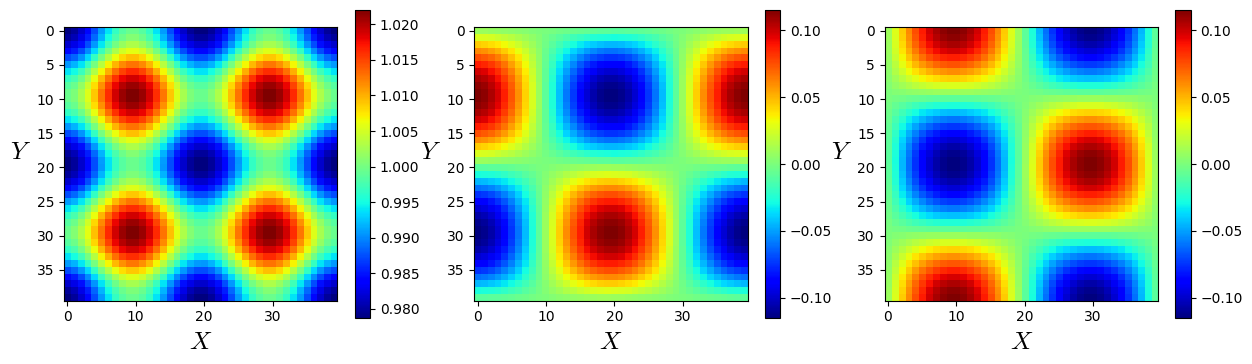

In [2]:
matplotlib.rcParams['mathtext.fontset'] = 'cm'
fig1, (ax1,ax2,ax3) = plt.subplots(ncols=3,figsize=(15,4))
img1=ax1.imshow(np.rot90(rho[:,:]),cmap='jet', interpolation='none')
fig1.colorbar(img1, ax=ax1)
ax1.set_xlabel('$X$',fontsize=18)
ax1.set_ylabel('$Y$',fontsize=18,horizontalalignment='right',rotation=0)
img2=ax2.imshow(np.rot90(Vx[:,:]),cmap='jet', interpolation='none')
fig1.colorbar(img2, ax=ax2)
ax2.set_xlabel('$X$',fontsize=18)
ax2.set_ylabel('$Y$',fontsize=18,horizontalalignment='right',rotation=0) 
img3=ax3.imshow(np.rot90(Vy[:,:]),cmap='jet', interpolation='none')
fig1.colorbar(img3, ax=ax3)
ax3.set_xlabel('$X$',fontsize=18)
ax3.set_ylabel('$Y$',fontsize=18,horizontalalignment='right',rotation=0) 

In [3]:
print(Enr[:])

[0.05034206 0.04991796 0.04949411 0.04907221 0.04865393 0.04824085
 0.04783427 0.04743518 0.04704414 0.04666135]


Text(0.5, 0, '$t$')

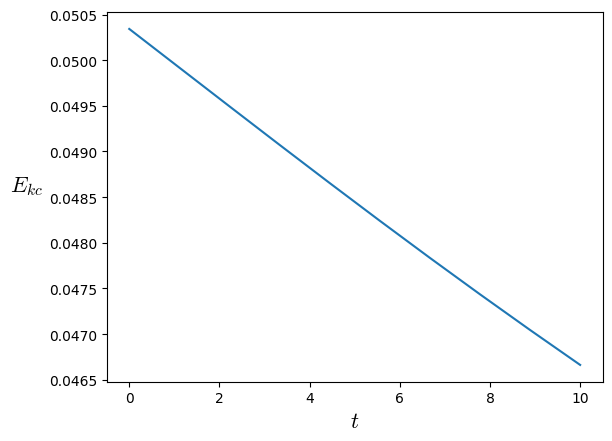

In [4]:
plt.plot(np.linspace(0,len(Enr),len(Enr)),Enr)
plt.ylabel('$E_{kc}$',fontsize=16,rotation=0,horizontalalignment='right')
plt.xlabel('$t$',fontsize=16)

Text(0.5, 0, '$t$')

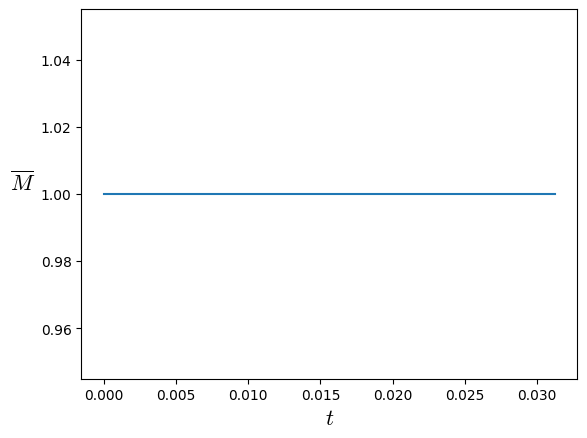

In [5]:
plt.plot(np.linspace(0,len(Mass),len(Mass))/Nx/r,Mass)
plt.ylabel('$\overline{M}$',fontsize=16,rotation=0,horizontalalignment='right')
plt.xlabel('$t$',fontsize=16)

In [6]:
import numpy as np
import matplotlib.pylab as plt
import matplotlib.colors
from IPython.display import display, Math, Latex
import time
Nx=40
Ny=Nx
# ---------------------------Lattice-Properties--------------------------------------------
w0=4.0/9.0;w1=1.0/9.0;w2=1.0/36.0; # Lattice Weights
w = np.array([w0,w1,w1,w1,w1,w2,w2,w2,w2],dtype="float64") 
cx = np.array([0,1,0,-1, 0,1,-1,-1, 1],dtype="int8")  # Lattice Directions
cy = np.array([0,0,1, 0,-1,1, 1,-1,-1],dtype="int8")  # Lattice Directions
# opp = np.array([0,3,4,1,2,7,8,5,6],dtype="uint8")  # Opposite Lattice Directions
#------------Dimensionless Parameter For Pro----------------
uo = 1.0 # Dimensionless Velocity
ho = 1.0 # Dimensionless Domain Length
Re = 30.0 # Reynolds Number
nuo = uo*ho/Re #Dimensionless Kinematic Viscosity
#------------------------------------------Scaling Term--------------------------------------------
dx = ho / (Nx) # Grid size 
r = 2.0**(3) # Relation term r=dx/dt
dt = dx / r # Time Step
#----------------------------------------LBM-Scale-----------------------------------------------
nu = dt * nuo / (dx * dx)  #Scaling Viscosity
ue = dt * uo / dx  #Scaling Velocity
cs = 1.0 / np.sqrt(3.) #Sound Speed
tau = (nu/ (cs * cs)) + (1.0/ 2.0) #Relaxation time
rhoi = 1.0 #Initial Densty
mstep=10
#--------------Print-Data-------------------------------------------------------------------------
display(Math(r"\tau="+str(tau)+r"\quad\quad \nu="+str(nu)))
display(Math(r"r="+str(r)+r"\quad\quad \overline{u}="+str(ue)))
display(Math(r"dx="+str(dx)+r"\quad\quad dt="+str(dt)))
#---------------------Field-Arrays---------------------------------------------------------------- 
Massf=np.zeros((mstep),dtype="float64") # Allocating Density field
Enrf=np.zeros((mstep),dtype="float64") # Allocating Density field
rhof=np.zeros((Nx,Ny),dtype="float64") # Allocating Density field
rhoVxf=np.zeros((Nx,Ny),dtype="float64") # Allocating Null Velocity x Field
rhoVyf=np.zeros((Nx,Ny),dtype="float64") # Allocating Null Velocity y Field
rhop=np.zeros((Nx,Ny),dtype="float64") # Allocating Density field
rhoVxp=np.zeros((Nx,Ny),dtype="float64") # Allocating Null Velocity x Field
rhoVyp=np.zeros((Nx,Ny),dtype="float64") # Allocating Null Velocity y Field
def derivatives(field, terms=None):
    if terms is None:
        terms = ['lap', 'grad_x', 'grad_y', 'grad_xx', 'grad_xy', 'grad_yy', 'grad_xxy', 'grad_xyy']
    # Compute neighbors (same as before)
    E = np.roll(field, -1, axis=0)
    W = np.roll(field,  1, axis=0)
    N = np.roll(field, -1, axis=1)
    S = np.roll(field,  1, axis=1)
    NE = np.roll(np.roll(field, -1, axis=0), -1, axis=1)
    NW = np.roll(np.roll(field,  1, axis=0), -1, axis=1)
    SE = np.roll(np.roll(field, -1, axis=0),  1, axis=1)
    SW = np.roll(np.roll(field,  1, axis=0),  1, axis=1)
    # Compute all derivatives
    all_terms = {
        'lap': (4.0 * (E + W + N + S) + NE + NW + SE + SW - 20.0 * field) / 36.0,
        'grad_x': (4.0 * (W - E) + NW - NE + SW - SE) / 36.0,
        'grad_y': (4.0 * (S - N) - NW - NE + SW + SE) / 36.0,
        'grad_xx': (4.0 * (W + E) + NW + NE + SW + SE) / 36.0,
        'grad_xy': (- NW + NE + SW - SE) / 36.0,
        'grad_yy': (4.0 * (S + N) + NW + NE + SW + SE) / 36.0,
        'grad_xxy': (- NW - NE + SW + SE) / 36.0,
        'grad_xyy': (+ NW - NE + SW - SE) / 36.0,
    }
    return [all_terms[term] for term in terms]
# ----------------------------Init Field------------------------------------------------------
xi = np.arange(Nx, dtype="float64") + 0.5
yi = np.arange(Ny, dtype="float64") + 0.5
Xi, Yi = np.meshgrid(xi, yi, indexing="ij")
rhof = rhoi - (rhoi * ue**2 / (4.0 * cs**2)) * (np.cos(4.0 * np.pi * Xi / Nx) + np.cos(4.0 * np.pi * Yi / Ny))    # Density
rhoVxf = -rhof*ue * (np.cos(2.0 * np.pi * Xi / Nx) * np.sin(2.0 * np.pi * Yi / Ny)) # Velocity X
rhoVyf = rhof*ue * (np.cos(2.0 * np.pi * Yi / Ny) * np.sin(2.0 * np.pi * Xi / Nx)) # Velocity Y
#---------------------------------Main-Loop-------------------------------------------------------
En=0.0; 
start=time.time()
for kk in range(0,mstep):
    lap_rho, grad_rho_x, grad_rho_y = derivatives(rhof, terms=['lap', 'grad_x', 'grad_y'])
    grad_rhoVx_x, grad_rhoVx_y, grad2_rhoVx_xx, grad2_rhoVx_xy, grad2_rhoVx_yy = derivatives(rhoVxf, terms=['grad_x', 'grad_y', 'grad_xx', 'grad_xy', 'grad_yy'])
    grad_rhoVy_x, grad_rhoVy_y, grad2_rhoVy_xx, grad2_rhoVy_xy, grad2_rhoVy_yy = derivatives(rhoVyf, terms=['grad_x', 'grad_y', 'grad_xx', 'grad_xy', 'grad_yy'])
    lap_rhoVxVx, grad_rhoVxVx_x, grad_rhoVxVx_y, grad2_rhoVxVx_xx, grad2_rhoVxVx_xy, grad2_rhoVxVx_yy, grad3_rhoVxVx_xxy, grad3_rhoVxVx_xyy = derivatives(rhoVxf*rhoVxf/rhof, terms=['lap', 'grad_x', 'grad_y', 'grad_xx', 'grad_xy', 'grad_yy', 'grad_xxy', 'grad_xyy']) 
    grad2_rhoVxVy_xx, grad2_rhoVxVy_xy, grad2_rhoVxVy_yy, grad3_rhoVxVy_xxy, grad3_rhoVxVy_xyy = derivatives(rhoVxf*rhoVyf/rhof, terms=['grad_xx', 'grad_xy', 'grad_yy', 'grad_xxy', 'grad_xyy'])
    lap_rhoVyVy, grad_rhoVyVy_x, grad_rhoVyVy_y, grad2_rhoVyVy_xx, grad2_rhoVyVy_xy, grad2_rhoVyVy_yy, grad3_rhoVyVy_xxy, grad3_rhoVyVy_xyy = derivatives(rhoVyf*rhoVyf/rhof, terms=['lap', 'grad_x', 'grad_y', 'grad_xx', 'grad_xy', 'grad_yy', 'grad_xxy', 'grad_xyy']) 
    rhop[:,:] = ( rhof[:,:] + lap_rho + 3.0*grad_rhoVx_x + 3.0*grad_rhoVy_y + 4.5*(grad2_rhoVxVx_xx + 2.0*grad2_rhoVxVy_xy + grad2_rhoVyVy_yy) 
                 - 1.5*(rhoVxf[:,:]*rhoVxf[:,:]/rhof[:,:] + rhoVyf[:,:]*rhoVyf[:,:]/rhof[:,:] + lap_rhoVxVx + lap_rhoVyVy) )
    rhoVxp[:,:] = ( grad_rho_x + 3.0*grad2_rhoVx_xx + 3.0*grad2_rhoVy_xy + 4.5*(grad_rhoVxVx_x + 2.0*grad3_rhoVxVy_xxy + grad3_rhoVyVy_xyy) 
                 - 1.5*(grad_rhoVxVx_x + grad_rhoVyVy_x) )
    rhoVyp[:,:] = ( grad_rho_y + 3.0*grad2_rhoVx_xy + 3.0*grad2_rhoVy_yy + 4.5*(grad3_rhoVxVx_xxy + 2.0*grad3_rhoVxVy_xyy + grad_rhoVyVy_y)
                 - 1.5*(grad_rhoVxVx_y + grad_rhoVyVy_y) )
    #--------------------------------------Macro-Properties------------------------------------------------------------------
    rhof[:,:] = rhop[:,:]
    rhoVxf[:,:] = rhoVxp[:,:]
    rhoVyf[:,:] = rhoVyp[:,:]
    #-------------------------------------Convergence------------------------------------------------------------------------
    Massf[kk] = np.sum(rhof)/(Nx*Ny)
    Umed = np.sum(np.abs(rhoVxf))/(Nx*Ny)
    print('|Umed|=',np.fabs(Umed) )
    Enrf[kk]=Umed

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

|Umed|= 0.05034177689121778
|Umed|= 0.04991721709500629
|Umed|= 0.049492799687946724
|Umed|= 0.04907026282895803
|Umed|= 0.04865134724847398
|Umed|= 0.04823765828018958
|Umed|= 0.047830545411106706
|Umed|= 0.04743100953298103
|Umed|= 0.047039645277748024
|Umed|= 0.04665662214106046


Text(0, 0.5, '$Y$')

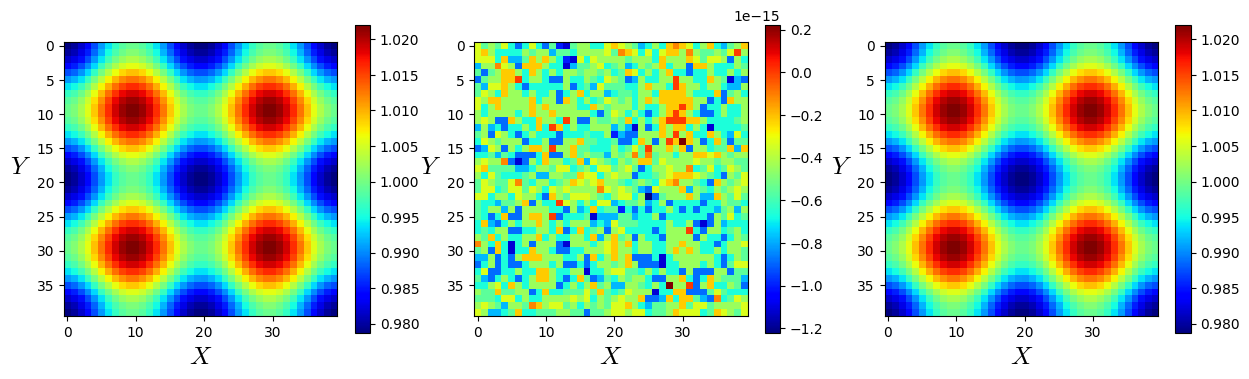

In [7]:
matplotlib.rcParams['mathtext.fontset'] = 'cm'
fig1, (ax1,ax2,ax3) = plt.subplots(ncols=3,figsize=(15,4))
img1=ax1.imshow(np.rot90(rhop[:,:]),cmap='jet', interpolation='none')
fig1.colorbar(img1, ax=ax1)
ax1.set_xlabel('$X$',fontsize=18)
ax1.set_ylabel('$Y$',fontsize=18,horizontalalignment='right',rotation=0)
img2=ax2.imshow(np.rot90(rho[:,:]-rhop[:,:]),cmap='jet', interpolation='none')
fig1.colorbar(img2, ax=ax2)
ax2.set_xlabel('$X$',fontsize=18)
ax2.set_ylabel('$Y$',fontsize=18,horizontalalignment='right',rotation=0) 
img3=ax3.imshow(np.rot90(rho[:,:]),cmap='jet', interpolation='none')
fig1.colorbar(img3, ax=ax3)
ax3.set_xlabel('$X$',fontsize=18)
ax3.set_ylabel('$Y$',fontsize=18,horizontalalignment='right',rotation=0) 

Text(0, 0.5, '$Y$')

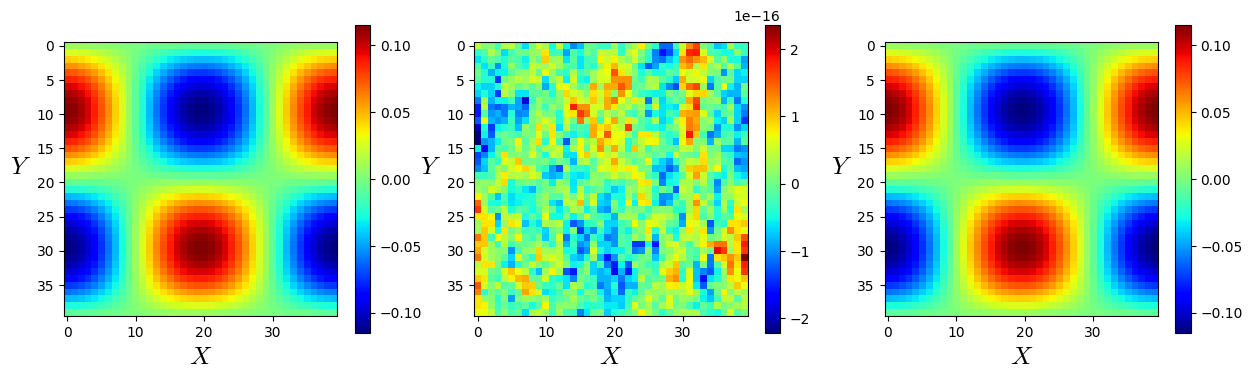

In [8]:
matplotlib.rcParams['mathtext.fontset'] = 'cm'
fig1, (ax1,ax2,ax3) = plt.subplots(ncols=3,figsize=(15,4))
img1=ax1.imshow(np.rot90(rhoVxp[:,:]),cmap='jet', interpolation='none')
fig1.colorbar(img1, ax=ax1)
ax1.set_xlabel('$X$',fontsize=18)
ax1.set_ylabel('$Y$',fontsize=18,horizontalalignment='right',rotation=0)
img2=ax2.imshow(np.rot90(rho[:,:]*Vx[:,:]-rhoVxp[:,:]),cmap='jet', interpolation='none')
fig1.colorbar(img2, ax=ax2)
ax2.set_xlabel('$X$',fontsize=18)
ax2.set_ylabel('$Y$',fontsize=18,horizontalalignment='right',rotation=0) 
img3=ax3.imshow(np.rot90(rho[:,:]*Vx[:,:]),cmap='jet', interpolation='none')
fig1.colorbar(img3, ax=ax3)
ax3.set_xlabel('$X$',fontsize=18)
ax3.set_ylabel('$Y$',fontsize=18,horizontalalignment='right',rotation=0) 

Text(0, 0.5, '$Y$')

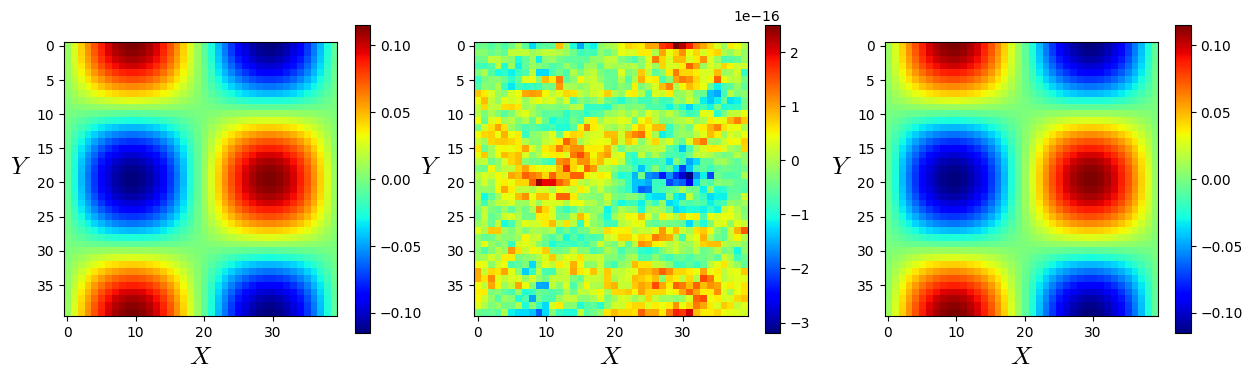

In [140]:
matplotlib.rcParams['mathtext.fontset'] = 'cm'
fig1, (ax1,ax2,ax3) = plt.subplots(ncols=3,figsize=(15,4))
img1=ax1.imshow(np.rot90(rhoVyp[:,:]),cmap='jet', interpolation='none')
fig1.colorbar(img1, ax=ax1)
ax1.set_xlabel('$X$',fontsize=18)
ax1.set_ylabel('$Y$',fontsize=18,horizontalalignment='right',rotation=0)
img2=ax2.imshow(np.rot90(rho[:,:]*Vy[:,:]-rhoVyp[:,:]),cmap='jet', interpolation='none')
fig1.colorbar(img2, ax=ax2)
ax2.set_xlabel('$X$',fontsize=18)
ax2.set_ylabel('$Y$',fontsize=18,horizontalalignment='right',rotation=0) 
img3=ax3.imshow(np.rot90(rho[:,:]*Vy[:,:]),cmap='jet', interpolation='none')
fig1.colorbar(img3, ax=ax3)
ax3.set_xlabel('$X$',fontsize=18)
ax3.set_ylabel('$Y$',fontsize=18,horizontalalignment='right',rotation=0) 